In [28]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pickle
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
from prophet import Prophet
from src.data_loader import load_data

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [21]:
data_path = Path('..') / 'data' / 'processed' / 'hourly_demand.parquet'
hourly_demand = pd.read_parquet(data_path)

for lag in [1, 2, 3, 24, 48, 168]:
    hourly_demand[f'lag_{lag}h'] = hourly_demand['ride_count'].shift(lag)

for window in [24, 168]:
    hourly_demand[f'rolling_mean_{window}h'] = hourly_demand['ride_count'].shift(1).rolling(window).mean()
    hourly_demand[f'rolling_std_{window}h']  = hourly_demand['ride_count'].shift(1).rolling(window).std()

hourly_demand.dropna(inplace=True)
hourly_demand.reset_index(drop=True, inplace=True)

print(hourly_demand.shape)
hourly_demand.head()

(4058, 12)


,ds,ride_count,lag_1h,lag_2h,lag_3h,lag_24h,lag_48h,lag_168h,rolling_mean_24h,rolling_std_24h,rolling_mean_168h,rolling_std_168h
0,2025-04-14 22:00:00,2966,4313.0,5944.0,8985.0,2592.0,1569.0,2214.0,4896.250000,3721.428107,3906.196429,3111.041544
1,2025-04-14 23:00:00,2001,2966.0,4313.0,5944.0,1575.0,1333.0,1699.0,4911.833333,3712.131073,3910.672619,3109.132625
2,2025-04-15 00:00:00,660,2001.0,2966.0,4313.0,987.0,1268.0,808.0,4929.583333,3696.467325,3912.470238,3107.933310
3,2025-04-15 01:00:00,367,660.0,2001.0,2966.0,459.0,939.0,399.0,4915.958333,3712.200502,3911.589286,3108.839394
4,2025-04-15 02:00:00,241,367.0,660.0,2001.0,290.0,675.0,238.0,4912.125000,3717.047336,3911.398810,3109.056869


In [4]:
test_size = 168
train = hourly_demand.iloc[:-test_size].copy()
test  = hourly_demand.iloc[-test_size:].copy()

print(f"Train: {len(train):,} rows  ({train['ds'].min()} ~ {train['ds'].max()})")
print(f"Test:  {len(test):,} rows   ({test['ds'].min()} ~ {test['ds'].max()})")

Train: 4,058 rows  (2025-04-07 22:00:00 ~ 2025-09-23 23:00:00)
Test:  168 rows   (2025-09-24 00:00:00 ~ 2025-09-30 23:00:00)


In [7]:
test = test.copy()
test["pred_baseline"] = test["lag_24h"]

mae_base  = mean_absolute_error(test["ride_count"], test["pred_baseline"])
rmse_base = np.sqrt(mean_squared_error(test["ride_count"], test["pred_baseline"]))
print(f"Baseline  MAE: {mae_base:,.2f}  RMSE: {rmse_base:,.2f}")

Baseline  MAE: 1,627.56  RMSE: 2,406.12


In [11]:
prophet_train = train[["ds", "ride_count"]].rename(columns={"ride_count": "y"})

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode="multiplicative"
)
model_prophet.fit(prophet_train)

future = model_prophet.make_future_dataframe(periods=test_size, freq="h")
forecast = model_prophet.predict(future)

test["pred_prophet"] = forecast["yhat"].iloc[-test_size:].values

mae_prophet  = mean_absolute_error(test["ride_count"], test["pred_prophet"])
rmse_prophet = np.sqrt(mean_squared_error(test["ride_count"], test["pred_prophet"]))
print(f"Prophet   MAE: {mae_prophet:,.2f}  RMSE: {rmse_prophet:,.2f}")

12:20:22 - cmdstanpy - INFO - Chain [1] start processing
12:20:22 - cmdstanpy - INFO - Chain [1] done processing


Prophet   MAE: 2,024.28  RMSE: 2,637.15


In [12]:
model_dir = Path.cwd().parent / "models"
model_dir.mkdir(exist_ok=True)

with open(model_dir / "prophet_model.pkl", "wb") as f:
    pickle.dump(model_prophet, f)

In [19]:
feature_cols = [
    "lag_1h", "lag_2h", "lag_3h", "lag_24h", "lag_48h", "lag_168h",
    "rolling_mean_24h", "rolling_std_24h",
    "rolling_mean_168h", "rolling_std_168h"
]

X_train = train[feature_cols]
y_train = train["ride_count"]
X_test  = test[feature_cols]
y_test  = test["ride_count"]

model_lgb = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    n_jobs=-1
)
model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

test["pred_lgb"] = model_lgb.predict(X_test)

mae_lgb  = mean_absolute_error(y_test, test["pred_lgb"])
rmse_lgb = np.sqrt(mean_squared_error(y_test, test["pred_lgb"]))  # y_test, pred_lgb 확인
print(f"LightGBM  MAE: {mae_lgb:,.2f}  RMSE: {rmse_lgb:,.2f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000637 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 4058, number of used features: 10
[LightGBM] [Info] Start training from score 6451.685067
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 530513
[200]	valid_0's l2: 481889
[300]	valid_0's l2: 467339
[400]	valid_0's l2: 457035
[500]	valid_0's l2: 450966
Did not meet early stopping. Best iteration is:
[500]	valid_0's l2: 450966
LightGBM  MAE: 440.41  RMSE: 671.54


In [20]:
results = pd.DataFrame({
    "Model":  ["Baseline (lag_24)", "Prophet", "LightGBM"],
    "MAE":    [mae_base, mae_prophet, mae_lgb],
    "RMSE":   [rmse_base, rmse_prophet, rmse_lgb]
})
print(results.to_string(index=False))

            Model         MAE        RMSE
Baseline (lag_24) 1627.559524 2406.115366
          Prophet 2024.283538 2637.152598
         LightGBM  440.409890  671.539835


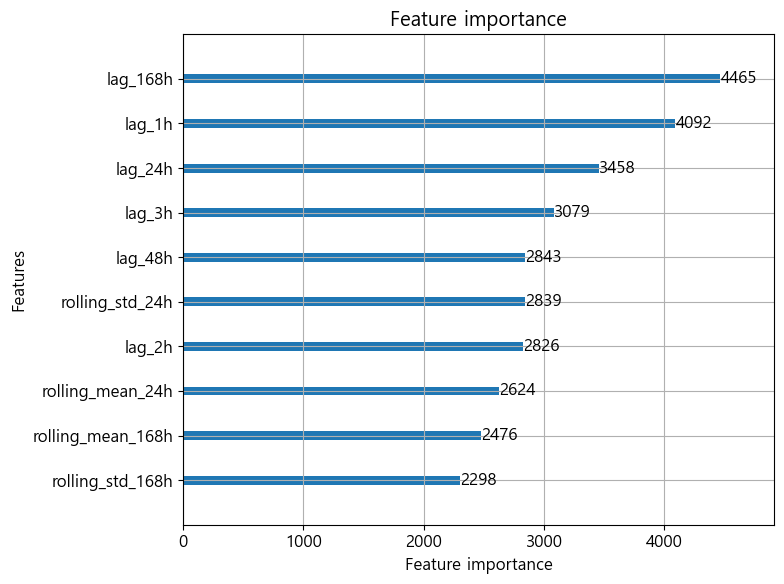

In [17]:
lgb.plot_importance(model_lgb, max_num_features=15, figsize=(8, 6))
plt.tight_layout()
plt.show()

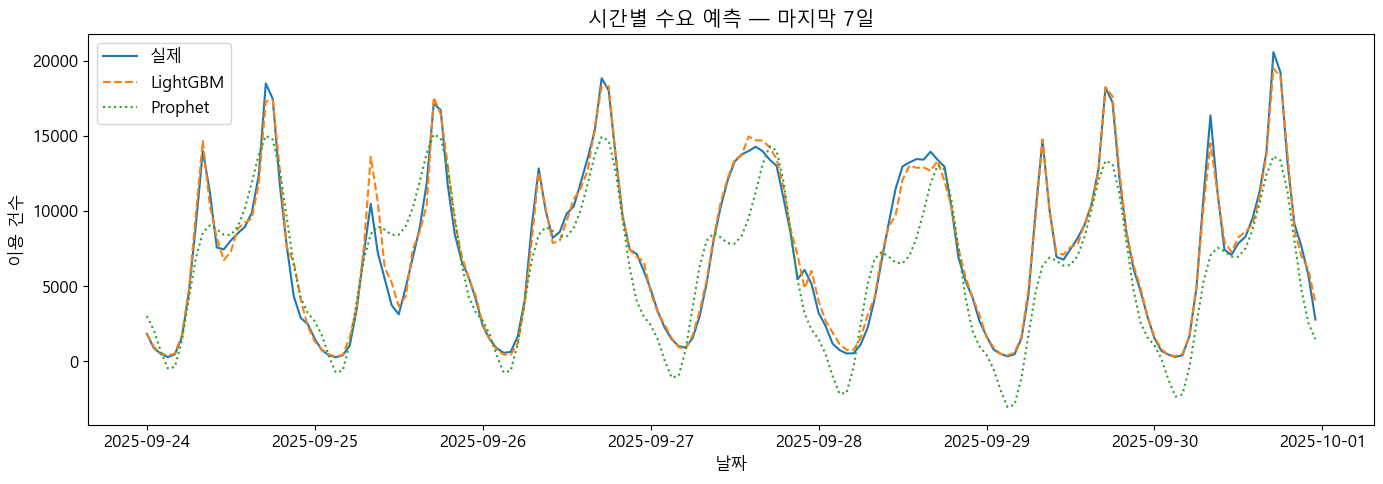

In [22]:
plt.figure(figsize=(14, 5))
plt.plot(test['ds'].values, test['ride_count'].values,   label='실제',      linewidth=1.5)
plt.plot(test['ds'].values, test['pred_lgb'].values,     label='LightGBM',  linewidth=1.5, linestyle='--')
plt.plot(test['ds'].values, test['pred_prophet'].values, label='Prophet',   linewidth=1.5, linestyle=':')
plt.title('시간별 수요 예측 — 마지막 7일')
plt.xlabel('날짜')
plt.ylabel('이용 건수')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
df = load_data()
df['duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60
df = df[(df['duration_min'] > 0) & (df['duration_min'] <= 180)].copy()
df['dayofweek'] = df['started_at'].dt.dayofweek
df['hour']      = df['started_at'].dt.hour
df['month']     = df['started_at'].dt.to_period('M')

Found 31 parquet file(s). Loading...
Loaded 28,206,527 records.
로드 완료: 28,165,708


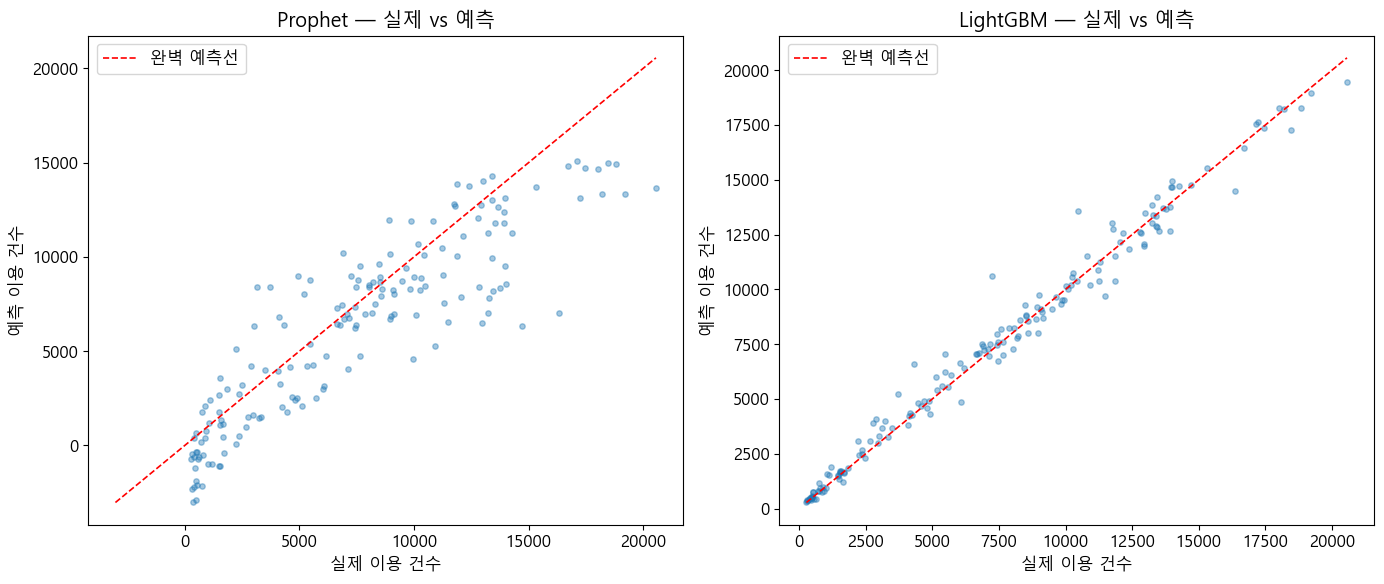

In [23]:
# 실제 vs 예측 산점도
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, y_pred) in zip(axes, [
    ('Prophet',  test['pred_prophet'].values),
    ('LightGBM', test['pred_lgb'].values)
]):
    ax.scatter(y_test.values, y_pred, alpha=0.4, s=15)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.2, label='완벽 예측선')
    ax.set_title(f'{label} — 실제 vs 예측')
    ax.set_xlabel('실제 이용 건수')
    ax.set_ylabel('예측 이용 건수')
    ax.legend()

plt.tight_layout()
plt.show()

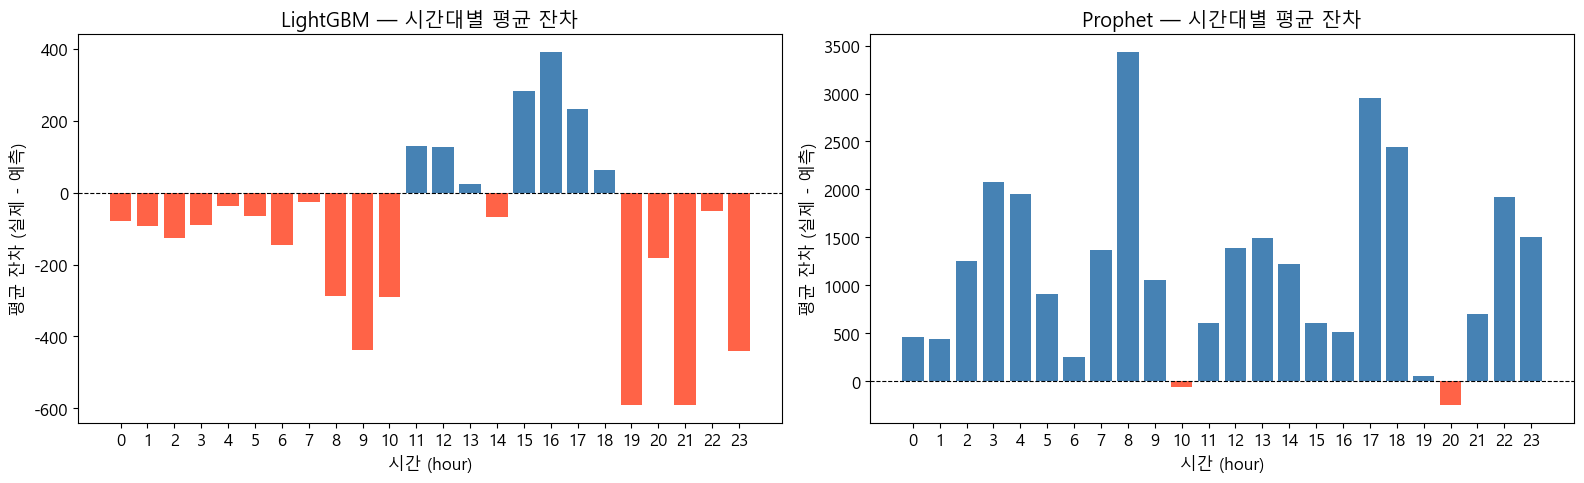

In [24]:
# 시간대별
test = test.copy()
test['residual_lgb']     = test['ride_count'] - test['pred_lgb']
test['residual_prophet'] = test['ride_count'] - test['pred_prophet']
test['hour'] = test['ds'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (label, col) in zip(axes, [
    ('LightGBM', 'residual_lgb'),
    ('Prophet',  'residual_prophet')
]):
    hourly_resid = test.groupby('hour')[col].mean()
    ax.bar(hourly_resid.index, hourly_resid.values,
           color=['tomato' if v < 0 else 'steelblue' for v in hourly_resid.values])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{label} — 시간대별 평균 잔차')
    ax.set_xlabel('시간 (hour)')
    ax.set_ylabel('평균 잔차 (실제 - 예측)')
    ax.set_xticks(range(0, 24))

plt.tight_layout()
plt.show()